/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:79: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.
/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:80: UserWarning: In Matplotlib 3.3 individual lines on a stem plot will be added as a LineCollection instead of individual lines. This significantly improves the performance of a stem plot. To remove this warning and switch to the new behaviour, set the "use_line_collection" keyword argument to True.


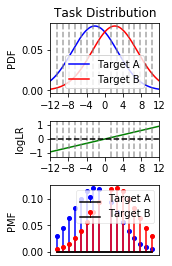

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
# Parameters for the symmetric Gaussians
mu = 2.2   # distance from y=0
sigma = 5.0
x = np.linspace(-15, 15, 500)

# Two symmetric Gaussian PDFs
pdf_left = norm.pdf(x, -mu, sigma)
pdf_right = norm.pdf(x, mu, sigma)

# Log ratio of PDFs
log_ratio = np.log10(pdf_right / pdf_left)

# Define target log ratio values
# target_log_ratios = np.array([-0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
# target_log_ratios = np.array([-0.9, -0.7, -0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7, 0.9])
target_log_ratios = np.array([-0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2, -0.1, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
# target_log_ratios = np.array([-0.3, 0.3])

# Find corresponding x values by interpolation
x_targets = np.interp(target_log_ratios, log_ratio, x)

# Plot with vertical lines at target x values
fig, ax = plt.subplots(3, 1, figsize=(2.5, 3.8), gridspec_kw={'height_ratios': [2, 1, 2]})

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

# Normalize
pB = pB_raw / pB_raw.sum()
pA = pA_raw / pA_raw.sum()

# --- New: set error rates ---
alpha = 0.05   # P_A(x > t_alpha) = α
beta  = 0.05   # P_B(x < t_beta)  = β

# --- Compute thresholds from quantiles ---
t_alpha = norm.ppf(1 - alpha, loc=-mu, scale=sigma)  # right-tail under A
t_beta  = norm.ppf(beta,      loc=+mu, scale=sigma)  # left-tail  under B

# Top plot: PDFs
ax[0].plot(x, pdf_left, label='Target A', color='blue')
ax[0].plot(x, pdf_right, label='Target B', color='red')

# # --- New: shade α and β error areas ---
# # α: under A ~ N(-mu, sigma), right tail x >= t_alpha (blue shade)
# ax[0].fill_between(x, 0, pdf_left, where=(x >= t_alpha), alpha=0.25, color='blue', label=r'$\alpha$ area')

# # β: under B ~ N(+mu, sigma), left tail x <= t_beta (red shade)
# ax[0].fill_between(x, 0, pdf_right, where=(x <= t_beta),  alpha=0.25, color='red',  label=r'$\beta$ area')

# draw decision thresholds as vertical lines (optional but helpful)
# ax[0].axvline(t_alpha, color='blue', linestyle=':', linewidth=1.5)
# ax[0].axvline(t_beta,  color='red',  linestyle=':', linewidth=1.5)

# keep your target x vertical lines
for xt in x_targets:
    ax[0].axvline(xt, color='gray', linestyle='--', alpha=0.7)

ax[0].set_xlim(-12, 12)
ax[0].set_xticks(range(-12, 13, 4))
ax[0].set_ylabel('PDF')
ax[0].legend()
ax[0].set_title('Task Distribution')

# middle plot: Log ratio
ax[1].plot(x, log_ratio, color='green')
for xt in x_targets:
    ax[1].axvline(xt, color='gray', linestyle='--', alpha=0.7)
ax[1].axhline(0, color='black', linestyle='--')
ax[1].set_xlim(-12, 12)
ax[1].set_xticks(range(-12, 13, 4))
# ax[1].set_xlabel('x')
ax[1].set_ylabel('logLR')

# bottom plot: Probability
markerline1, stemlines1, baseline1 = ax[2].stem(x_targets, pA, linefmt='b-', markerfmt='bo', basefmt='k-', label='Target A')
markerline2, stemlines2, baseline2 = ax[2].stem(x_targets, pB, linefmt='r-', markerfmt='ro', basefmt='k-', label='Target B')
markerline1.set_markersize(4)
markerline2.set_markersize(4)
ax[2].legend()
ax[2].set_xlim(-12, 12)
ax[2].set_xticks(range(-12, 13, 4))
# ax[2].set_ylim(0, 0.25)
ax[2].set_xlabel('x')
ax[2].set_ylabel('PMF')

# hide the xticks
ax[2].set_xticks([])
# hide the xlabel
ax[2].set_xlabel('')

leg2 = ax[2].get_legend()
leg2.get_frame().set_linewidth(0.5)
for lh in leg2.get_lines():
    lh.set_linewidth(1.0)
    lh.set_markersize(3.0)

plt.tight_layout()

# save the figure to svg
plt.savefig('distribution.svg', dpi=300)

plt.show()

Value iteration converged after 39 iterations.
V_star shape: (1001,)
First few values: [1.    0.999 0.998 0.997 0.996]
Last few values: [0.996 0.997 0.998 0.999 1.   ]


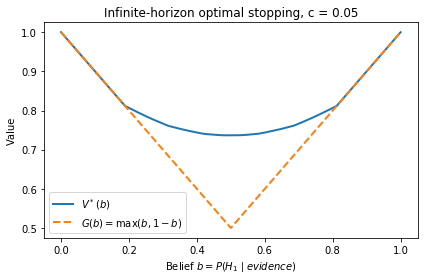

In [5]:
# ============================================================
# Infinite-horizon optimal stopping by value iteration
# Belief state: b = P(Target B | observations)
# H1 = Target B, H0 = Target A
# ============================================================

# Sampling cost
c = 0.   # change this value as needed

# Terminal rewards
R_correct = 1.0
R_wrong = 0.0

# Belief grid
N_b = 1001
b_grid = np.linspace(0, 1, N_b)

# Immediate stopping value:
# choose H1 if b >= 0.5, choose H0 otherwise
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

# Initialize value function
V = G.copy()

# Value iteration settings
tol = 1e-10
max_iter = 100000

def interp_value(b_next, b_grid, V):
    """
    Linear interpolation of V on the belief grid.
    """
    return np.interp(b_next, b_grid, V)

for iteration in range(max_iter):

    V_old = V.copy()
    continue_value = np.zeros_like(b_grid)

    for j, b in enumerate(b_grid):

        expected_future_value = 0.0

        for i in range(len(pA)):

            # Predictive probability of observing shape i
            q_i = b * pB[i] + (1 - b) * pA[i]

            if q_i > 0:
                # Bayesian belief update:
                # b_next = P(Target B | observed shape i)
                b_next = (b * pB[i]) / q_i

                expected_future_value += q_i * interp_value(
                    b_next, b_grid, V_old
                )

        continue_value[j] = -c + expected_future_value

    # Bellman optimality update
    V = np.maximum(G, continue_value)

    diff = np.max(np.abs(V - V_old))

    if diff < tol:
        print(f"Value iteration converged after {iteration + 1} iterations.")
        break

else:
    print("Warning: value iteration did not converge within max_iter.")

# Store converged infinite-horizon value function
V_star = V.copy()

print("V_star shape:", V_star.shape)
print("First few values:", V_star[:5])
print("Last few values:", V_star[-5:])

# ============================================================
# Plot V*(b) together with terminal stopping value G(b)
# ============================================================

plt.figure(figsize=(6, 4))
plt.plot(b_grid, V_star, label=r"$V^*(b)$", linewidth=2)
plt.plot(b_grid, G, "--", label=r"$G(b)=\max(b,1-b)$", linewidth=2)

plt.xlabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.ylabel("Value")
plt.title(f"Infinite-horizon optimal stopping, c = {c}")
plt.legend()
plt.tight_layout()
plt.show()

c=0.01: V* converged after 84 iterations.
c=0.01: continue region = [0.034, 0.966]
c=0.02: V* converged after 69 iterations.
c=0.02: continue region = [0.073, 0.927]
c=0.03: V* converged after 56 iterations.
c=0.03: continue region = [0.112, 0.888]
c=0.04: V* converged after 47 iterations.
c=0.04: continue region = [0.151, 0.849]
c=0.05: V* converged after 39 iterations.
c=0.05: continue region = [0.188, 0.812]


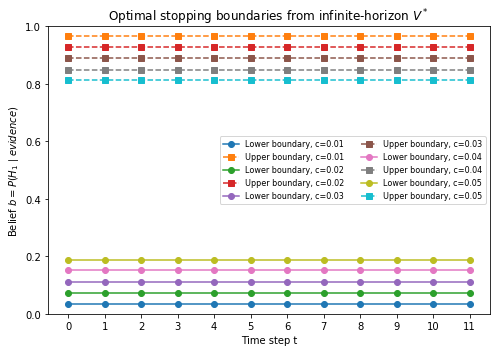

In [7]:
# ============================================================
# Optimal stopping boundaries from V_star
# For c = .01, .02, .03, .04, .05
# t = 0,...,11
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Belief grid
N_b = 1001
b_grid = np.linspace(0, 1, N_b)

# Time grid
t_grid = np.arange(12)  # 0 to 11

# Terminal rewards
R_correct = 1.0
R_wrong = 0.0

# Stop value G(b)
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

def compute_V_star(pA, pB, c, b_grid, G, tol=1e-10, max_iter=100000):
    """
    Infinite-horizon value iteration.
    Belief b = P(H1 | evidence), where H1 corresponds to pB.
    H0 corresponds to pA.
    """
    V = G.copy()

    for iteration in range(max_iter):
        V_old = V.copy()
        continue_value = np.zeros_like(b_grid)

        for j, b in enumerate(b_grid):
            expected_future_value = 0.0

            for i in range(len(pA)):
                q_i = b * pB[i] + (1 - b) * pA[i]

                if q_i > 0:
                    b_next = (b * pB[i]) / q_i
                    expected_future_value += q_i * np.interp(
                        b_next, b_grid, V_old
                    )

            continue_value[j] = -c + expected_future_value

        V = np.maximum(G, continue_value)

        diff = np.max(np.abs(V - V_old))
        if diff < tol:
            print(f"c={c:.2f}: V* converged after {iteration + 1} iterations.")
            break

    return V


def stopping_boundaries_from_Vstar(pA, pB, c, b_grid, G, V_star):
    """
    Compute stopping region using:
    V_t(b) = max{G(b), -c + sum_i q_i(b) V_star(tau_i(b))}
    
    Returns lower and upper stopping boundaries:
    stop for b <= lower_boundary or b >= upper_boundary.
    Continue for beliefs between them.
    """
    continue_value = np.zeros_like(b_grid)

    for j, b in enumerate(b_grid):
        expected_future_value = 0.0

        for i in range(len(pA)):
            q_i = b * pB[i] + (1 - b) * pA[i]

            if q_i > 0:
                b_next = (b * pB[i]) / q_i
                expected_future_value += q_i * np.interp(
                    b_next, b_grid, V_star
                )

        continue_value[j] = -c + expected_future_value

    stop_value = G
    stop_region = stop_value >= continue_value

    continue_region = ~stop_region

    if np.any(continue_region):
        lower_boundary = b_grid[continue_region][0]
        upper_boundary = b_grid[continue_region][-1]
    else:
        lower_boundary = 0.5
        upper_boundary = 0.5

    return lower_boundary, upper_boundary, stop_region, continue_value


# ============================================================
# Loop over sampling costs
# ============================================================

c_values = [0.01, 0.02, 0.03, 0.04, 0.05]

lower_boundaries = {}
upper_boundaries = {}
V_stars = {}

for c in c_values:
    V_star = compute_V_star(pA, pB, c, b_grid, G)
    V_stars[c] = V_star

    lower_b, upper_b, stop_region, continue_value = stopping_boundaries_from_Vstar(
        pA, pB, c, b_grid, G, V_star
    )

    # Same boundary for every t because RHS uses V_star
    lower_boundaries[c] = np.full_like(t_grid, lower_b, dtype=float)
    upper_boundaries[c] = np.full_like(t_grid, upper_b, dtype=float)

    print(
        f"c={c:.2f}: continue region = "
        f"[{lower_b:.3f}, {upper_b:.3f}]"
    )


# ============================================================
# Plot boundaries over time
# ============================================================

plt.figure(figsize=(7, 5))

for c in c_values:
    plt.plot(
        t_grid,
        lower_boundaries[c],
        marker="o",
        label=f"Lower boundary, c={c:.2f}"
    )

    plt.plot(
        t_grid,
        upper_boundaries[c],
        marker="s",
        linestyle="--",
        label=f"Upper boundary, c={c:.2f}"
    )

plt.xlabel("Time step t")
plt.ylabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.title("Optimal stopping boundaries from infinite-horizon $V^*$")
plt.ylim(0, 1)
plt.xticks(t_grid)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# When there is a deadline


c = 0.01
t= 0: lower=0.039, upper=0.961
t= 1: lower=0.04, upper=0.96
t= 2: lower=0.042, upper=0.9580000000000001
t= 3: lower=0.044, upper=0.9560000000000001
t= 4: lower=0.047, upper=0.9530000000000001
t= 5: lower=0.053, upper=0.9470000000000001
t= 6: lower=0.061, upper=0.9390000000000001
t= 7: lower=0.076, upper=0.924
t= 8: lower=0.113, upper=0.887
t= 9: lower=0.198, upper=0.802
t=10: lower=0.5, upper=0.5
t=11: lower=nan, upper=nan

c = 0.02
t= 0: lower=0.076, upper=0.924
t= 1: lower=0.077, upper=0.923
t= 2: lower=0.079, upper=0.921
t= 3: lower=0.081, upper=0.919
t= 4: lower=0.085, upper=0.915
t= 5: lower=0.09, upper=0.91
t= 6: lower=0.099, upper=0.901
t= 7: lower=0.114, upper=0.886
t= 8: lower=0.149, upper=0.851
t= 9: lower=0.242, upper=0.758
t=10: lower=0.5, upper=0.5
t=11: lower=nan, upper=nan

c = 0.03
t= 0: lower=0.114, upper=0.886
t= 1: lower=0.115, upper=0.885
t= 2: lower=0.116, upper=0.884
t= 3: lower=0.11800000000000001, upper=0.882
t= 4: lower=0.121, upper=0.879
t= 5: lower=

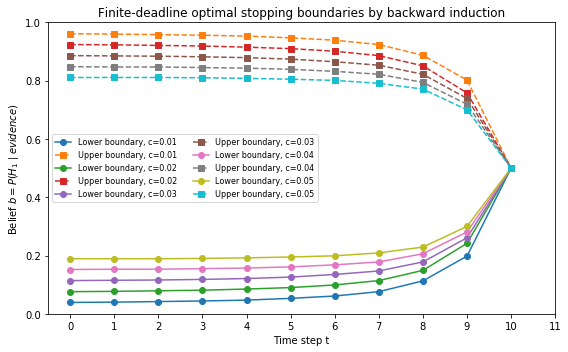

In [8]:
# ============================================================
# Finite-deadline optimal stopping by backward induction
# Deadline: t = 11
# Terminal value: V_11(b) = 0 everywhere
# Costs: c = .01, .02, .03, .04, .05
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Belief grid
N_b = 1001
b_grid = np.linspace(0, 1, N_b)

# Time grid
T_deadline = 11
t_grid = np.arange(T_deadline + 1)  # 0,...,11

# Terminal rewards
R_correct = 1.0
R_wrong = 0.0

# Stopping value for t < 11
G = np.maximum(
    b_grid * R_correct + (1 - b_grid) * R_wrong,
    (1 - b_grid) * R_correct + b_grid * R_wrong
)

# At the deadline, value is fixed at zero everywhere
G_deadline = np.zeros_like(b_grid)

c_values = [0.01, 0.02, 0.03, 0.04, 0.05]

all_lower_boundaries = {}
all_upper_boundaries = {}
all_V = {}

for c in c_values:

    # V[t, j] = value at time t and belief b_grid[j]
    V = np.zeros((T_deadline + 1, N_b))

    # Deadline condition
    V[T_deadline, :] = G_deadline

    lower_boundary = np.full(T_deadline + 1, np.nan)
    upper_boundary = np.full(T_deadline + 1, np.nan)

    # At t = 11, no stopping boundary is meaningful because value is fixed at 0
    lower_boundary[T_deadline] = np.nan
    upper_boundary[T_deadline] = np.nan

    # Backward induction: t = 10, 9, ..., 0
    for t in range(T_deadline - 1, -1, -1):

        continue_value = np.zeros_like(b_grid)

        for j, b in enumerate(b_grid):

            expected_future_value = 0.0

            # If t >= 10, assume no new information arrives.
            # The agent can only move to t+1 and pay cost c.
            if t >= 10:
                expected_future_value = np.interp(b, b_grid, V[t + 1, :])

            else:
                # Bayesian predictive update with new observation
                for i in range(len(pA)):

                    q_i = b * pB[i] + (1 - b) * pA[i]

                    if q_i > 0:
                        b_next = (b * pB[i]) / q_i

                        expected_future_value += q_i * np.interp(
                            b_next,
                            b_grid,
                            V[t + 1, :]
                        )

            continue_value[j] = -c + expected_future_value

        # Stop value is normal G(b) for t < 11
        stop_value = G

        # Bellman update
        V[t, :] = np.maximum(stop_value, continue_value)

        # Continue region
        continue_region = continue_value > stop_value

        if np.any(continue_region):
            lower_boundary[t] = b_grid[continue_region][0]
            upper_boundary[t] = b_grid[continue_region][-1]
        else:
            # No continuation region
            lower_boundary[t] = 0.5
            upper_boundary[t] = 0.5

    all_lower_boundaries[c] = lower_boundary
    all_upper_boundaries[c] = upper_boundary
    all_V[c] = V

    print(f"\nc = {c:.2f}")
    for t in range(T_deadline + 1):
        print(
            f"t={t:2d}: "
            f"lower={lower_boundary[t]}, "
            f"upper={upper_boundary[t]}"
        )


# ============================================================
# Plot optimal stopping boundaries
# ============================================================

plt.figure(figsize=(8, 5))

for c in c_values:

    plt.plot(
        t_grid,
        all_lower_boundaries[c],
        marker="o",
        label=f"Lower boundary, c={c:.2f}"
    )

    plt.plot(
        t_grid,
        all_upper_boundaries[c],
        marker="s",
        linestyle="--",
        label=f"Upper boundary, c={c:.2f}"
    )

plt.xlabel("Time step t")
plt.ylabel(r"Belief $b=P(H_1 \mid evidence)$")
plt.title("Finite-deadline optimal stopping boundaries by backward induction")
plt.ylim(0, 1)
plt.xticks(t_grid)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

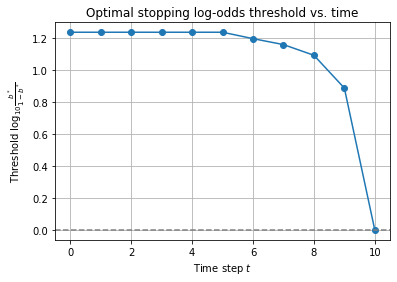

In [16]:
import numpy as np

# --- 1. Define evidence distributions from Input16.py ---
# 16 log10-likelihood ratios (for evidence 1..16)
log10_ratio = np.array([-0.9, -0.8, -0.7, -0.6, -0.5, -0.4, -0.3, -0.2,
                         0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9])
# Assume P(evidence|H0) uniform:
p0 = np.ones(16)/16  
# Solve for P(evidence|H1) to match the log ratios
p1 = p0 * (10**log10_ratio)
p1 /= p1.sum()

# --- 2. DP parameters ---
c = 0.03             # cost per sample
T = 11               # horizon time (V_T = 0 for all b)
Ngrid = 201          # number of grid points for belief b
bs = np.linspace(0,1,Ngrid)
bs = np.clip(bs,1e-6,1-1e-6)  # avoid exact 0,1

# Pre-generate Gaussian noise samples for expectation
M = 50
eps_samples = np.random.randn(M)

# Initialize value table V[t,b_index]
V = np.zeros((T+1, Ngrid))
# V[T,:] stays zero (no future reward possible at final state)

# Define interpolation for V[t+1] at arbitrary b
def interp_V(V_next, bvals):
    return np.interp(bvals, bs, V_next)

# --- 3. Backward induction ---
for t in reversed(range(T)):  # from T-1 down to 0
    for ib, b in enumerate(bs):
        # Stopping reward
        G = max(b, 1-b)
        # Continuation value
        if t == T-1:
            # If next is terminal with no info, continuation yields -c + 0
            C = -c
        else:
            exp_V = 0.0
            z = np.log10(b/(1-b))  # current log-odds
            # Sum expectation over evidence i
            for i in range(16):
                pi = b*p1[i] + (1-b)*p0[i]
                if pi == 0: 
                    continue
                # Update log-odds for M noise samples
                z_new = z + log10_ratio[i] + eps_samples
                b_new = 10**(z_new) / (1 + 10**(z_new))
                # Clamp beliefs to [0,1] and interpolate V[t+1]
                b_new = np.clip(b_new, 0, 1)
                V_vals = interp_V(V[t+1], b_new)
                exp_V += pi * np.mean(V_vals)
            C = -c + exp_V
        # Optimal value
        V[t, ib] = max(G, C)

# --- 4. Extract stopping threshold for each t ---
thresholds = np.zeros(T)
for t in range(T):
    # find smallest b >= 0.5 where stopping dominates
    stop_mask = (bs>=0.5) & (V[t] == np.maximum(bs, 1-bs))
    if np.any(stop_mask):
        thresholds[t] = bs[stop_mask][0]
    else:
        thresholds[t] = 1.0  # if no stopping region on [0.5,1], set to 1

# Convert threshold beliefs to log-odds (log10):
logodds_thr = np.log10(thresholds / (1-thresholds))

# --- 5. Plot threshold over time ---
import matplotlib.pyplot as plt

ts = np.arange(0, T)  # t = 0..10
plt.figure(figsize=(6,4))
plt.plot(ts, logodds_thr, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Time step $t$')
plt.ylabel('Threshold $\log_{10}\\frac{b^*}{1-b^*}$')
plt.title('Optimal stopping log-odds threshold vs. time')
plt.grid(True)
plt.show()

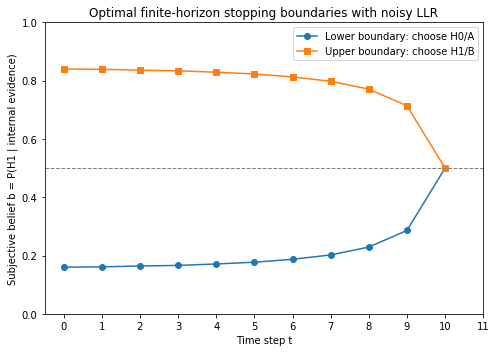

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ============================================================
# 1. Load / recreate pA and pB from Input16.py
# ============================================================

mu = 2.2
sigma = 5.0
x = np.linspace(-15, 15, 500)

pdf_left = norm.pdf(x, -mu, sigma)   # H0 / A
pdf_right = norm.pdf(x, mu, sigma)   # H1 / B

log_ratio_curve = np.log10(pdf_right / pdf_left)

target_log_ratios = np.array([
    -0.8, -0.7, -0.6, -0.5,
    -0.4, -0.3, -0.2, -0.1,
     0.1,  0.2,  0.3,  0.4,
     0.5,  0.6,  0.7,  0.8
])

x_targets = np.interp(target_log_ratios, log_ratio_curve, x)

pB_raw = norm.pdf(x_targets, mu, sigma)
pA_raw = norm.pdf(x_targets, -mu, sigma)

pB = pB_raw / pB_raw.sum()   # H1
pA = pA_raw / pA_raw.sum()   # H0

# Ground-truth log10 likelihood ratio for each evidence symbol
true_llr = np.log10(pB / pA)

# ============================================================
# 2. Parameters
# ============================================================

c = 0.03
T = 11
sigma_llr_noise = .2

N_b = 1001
b_grid = np.linspace(1e-6, 1 - 1e-6, N_b)

# Monte Carlo samples for Gaussian noise expectation in DP
N_noise_dp = 101
noise_samples = np.linspace(-4, 4, N_noise_dp)
noise_weights = norm.pdf(noise_samples, 0, sigma_llr_noise)
noise_weights = noise_weights / noise_weights.sum()

# ============================================================
# 3. Helper functions
# ============================================================

def b_to_logodds10(b):
    return np.log10(b / (1 - b))

def logodds10_to_b(z):
    z = np.clip(z, -12, 12)
    return 1 / (1 + 10 ** (-z))

def interp_value(V_next, b_next):
    return np.interp(b_next, b_grid, V_next)

# ============================================================
# 4. Backward induction with noisy LLR update
# ============================================================

V = np.zeros((T + 1, N_b))
policy_stop = np.zeros((T + 1, N_b), dtype=bool)

# Deadline condition:
# V_11(b) = 0 everywhere
V[T, :] = 0.0

G_all = np.maximum(b_grid, 1 - b_grid)

for t in range(T - 1, -1, -1):

    for j, b in enumerate(b_grid):

        G = max(b, 1 - b)

        # If t >= 10, no new information arrives.
        # Continuing only pays cost and moves to next time.
        if t >= 10:
            C = -c + np.interp(b, b_grid, V[t + 1, :])

        else:
            z = b_to_logodds10(b)
            expected_future = 0.0

            for i in range(len(pA)):

                # Predictive probability under subjective belief
                q_i = (1 - b) * pA[i] + b * pB[i]

                # Noisy subjective log-odds update
                z_next = z + true_llr[i] + noise_samples
                b_next = logodds10_to_b(z_next)

                future_vals = interp_value(V[t + 1, :], b_next)

                expected_future += q_i * np.sum(noise_weights * future_vals)

            C = -c + expected_future

        V[t, j] = max(G, C)
        policy_stop[t, j] = G >= C

# ============================================================
# 5. Extract lower and upper stopping boundaries
# ============================================================

lower_boundary = np.full(T + 1, np.nan)
upper_boundary = np.full(T + 1, np.nan)

for t in range(T):

    stop_mask = policy_stop[t, :]

    # Continue region is the middle region where stop is false
    continue_mask = ~stop_mask

    if np.any(continue_mask):
        lower_boundary[t] = b_grid[continue_mask][0]
        upper_boundary[t] = b_grid[continue_mask][-1]
    else:
        # No continuation region: stop everywhere
        lower_boundary[t] = 0.5
        upper_boundary[t] = 0.5

# ============================================================
# 6. Plot subjective-belief stopping boundaries
# ============================================================

t_grid = np.arange(T + 1)

plt.figure(figsize=(7, 5))
plt.plot(t_grid, lower_boundary, marker="o", label="Lower boundary: choose H0/A")
plt.plot(t_grid, upper_boundary, marker="s", label="Upper boundary: choose H1/B")
plt.axhline(0.5, linestyle="--", linewidth=1, color="gray")

plt.xlabel("Time step t")
plt.ylabel("Subjective belief b = P(H1 | internal evidence)")
plt.title("Optimal finite-horizon stopping boundaries with noisy LLR")
plt.ylim(0, 1)
plt.xticks(t_grid)
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
# ============================================================
# 7. Simulate 500,000 trials using the deterministic boundary
# ============================================================

N_trials = 500_000
rng = np.random.default_rng(1)

H = rng.integers(0, 2, size=N_trials)  # 0 = A/H0, 1 = B/H1

alive = np.ones(N_trials, dtype=bool)
chosen = np.full(N_trials, -1, dtype=int)  # 0 = choose A/H0, 1 = choose B/H1
rt = np.full(N_trials, -1, dtype=int)

subjective_z = np.zeros(N_trials)
groundtruth_z = np.zeros(N_trials)

# Store per-time diagnostic states
records = []

for t in range(T):

    idx_alive = np.where(alive)[0]

    if len(idx_alive) == 0:
        break

    b_subj = logodds10_to_b(subjective_z[idx_alive])

    # Apply boundary
    choose_A = b_subj <= lower_boundary[t]
    choose_B = b_subj >= upper_boundary[t]
    do_stop = choose_A | choose_B

    idx_stop = idx_alive[do_stop]
    idx_wait = idx_alive[~do_stop]

    chosen[idx_alive[choose_A]] = 0
    chosen[idx_alive[choose_B]] = 1
    rt[idx_stop] = t

    # Store diagnostic distribution at this time BEFORE new sampling
    records.append({
        "t": t,
        "llr_choose_A": groundtruth_z[idx_alive[choose_A]].copy(),
        "llr_choose_B": groundtruth_z[idx_alive[choose_B]].copy(),
        "llr_wait": groundtruth_z[idx_wait].copy(),
        "n_remaining_at_t": len(idx_alive)
    })

    alive[idx_stop] = False

    # No information after t >= 10
    if t >= 10:
        continue

    # Sample next evidence for waiting trials
    idx_alive = np.where(alive)[0]

    if len(idx_alive) == 0:
        break

    # Draw evidence conditional on true hypothesis
    idx_A = idx_alive[H[idx_alive] == 0]
    idx_B = idx_alive[H[idx_alive] == 1]

    ev_A = rng.choice(len(pA), size=len(idx_A), p=pA)
    ev_B = rng.choice(len(pB), size=len(idx_B), p=pB)

    # Update ground-truth LLR
    groundtruth_z[idx_A] += true_llr[ev_A]
    groundtruth_z[idx_B] += true_llr[ev_B]

    # Update subjective noisy LLR
    subjective_z[idx_A] += true_llr[ev_A] + rng.normal(0, sigma_llr_noise, size=len(idx_A))
    subjective_z[idx_B] += true_llr[ev_B] + rng.normal(0, sigma_llr_noise, size=len(idx_B))

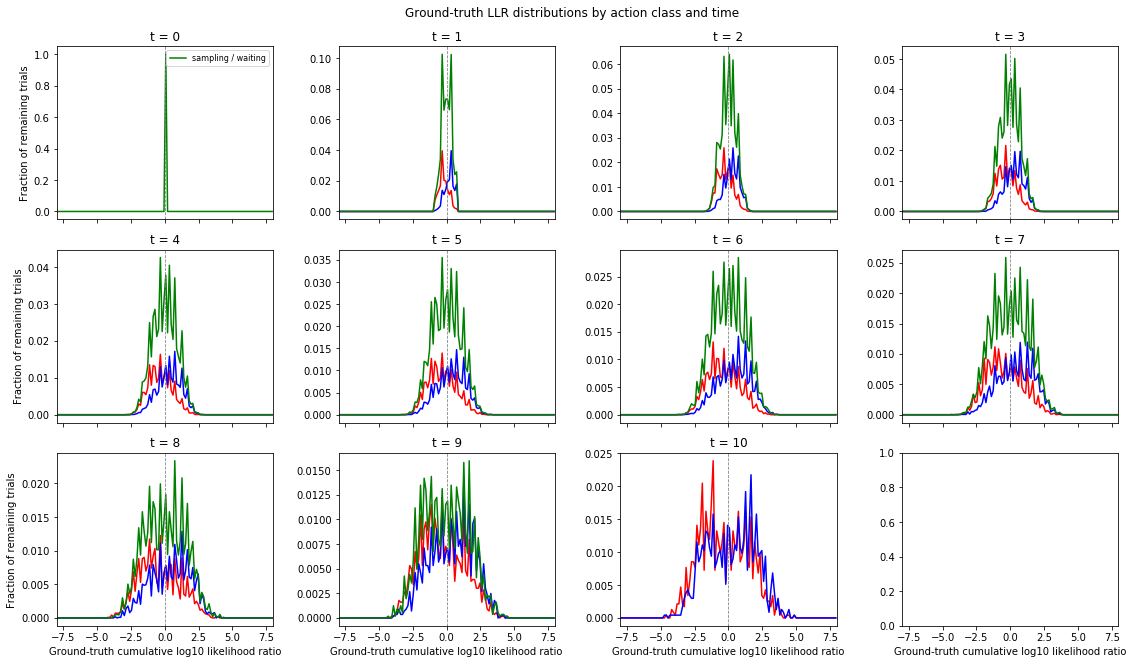

Fraction chosen A: 0.499444
Fraction chosen B: 0.500556
Fraction never stopped: 0.0
Mean RT: 2.54309

Boundaries:
t= 0: lower=0.0900, upper=0.9100
t= 1: lower=0.0900, upper=0.9100
t= 2: lower=0.0910, upper=0.9090
t= 3: lower=0.0920, upper=0.9080
t= 4: lower=0.0930, upper=0.9070
t= 5: lower=0.0970, upper=0.9030
t= 6: lower=0.1020, upper=0.8980
t= 7: lower=0.1130, upper=0.8870
t= 8: lower=0.1360, upper=0.8640
t= 9: lower=0.1910, upper=0.8090
t=10: lower=0.5000, upper=0.5000
t=11: lower=0.0000, upper=1.0000


In [22]:
# ============================================================
# 8. Plot ground-truth LLR distributions by time and action
# ============================================================

bins = np.linspace(-8, 8, 121)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True, sharey=False)
axes = axes.ravel()

for rec in records:

    t = rec["t"]
    ax = axes[t]

    n_rem = rec["n_remaining_at_t"]

    for data, color, label in [
        (rec["llr_choose_A"], "red", "chosen A / H0"),
        (rec["llr_choose_B"], "blue", "chosen B / H1"),
        (rec["llr_wait"], "green", "sampling / waiting"),
    ]:
        if len(data) == 0:
            continue

        counts, _ = np.histogram(data, bins=bins)

        # Normalize height by number of remaining trials at this time
        height = counts / n_rem

        ax.plot(bin_centers, height, color=color, linewidth=1.5, label=label)

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"t = {t}")
    ax.set_xlim(bins[0], bins[-1])

axes[0].legend(fontsize=8)

for ax in axes[-4:]:
    ax.set_xlabel("Ground-truth cumulative log10 likelihood ratio")

for ax in axes[::4]:
    ax.set_ylabel("Fraction of remaining trials")

plt.suptitle("Ground-truth LLR distributions by action class and time", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 9. Optional summary statistics
# ============================================================

print("Fraction chosen A:", np.mean(chosen == 0))
print("Fraction chosen B:", np.mean(chosen == 1))
print("Fraction never stopped:", np.mean(chosen == -1))
print("Mean RT:", np.mean(rt[rt >= 0]))

print("\nBoundaries:")
for t in range(T + 1):
    print(f"t={t:2d}: lower={lower_boundary[t]:.4f}, upper={upper_boundary[t]:.4f}")

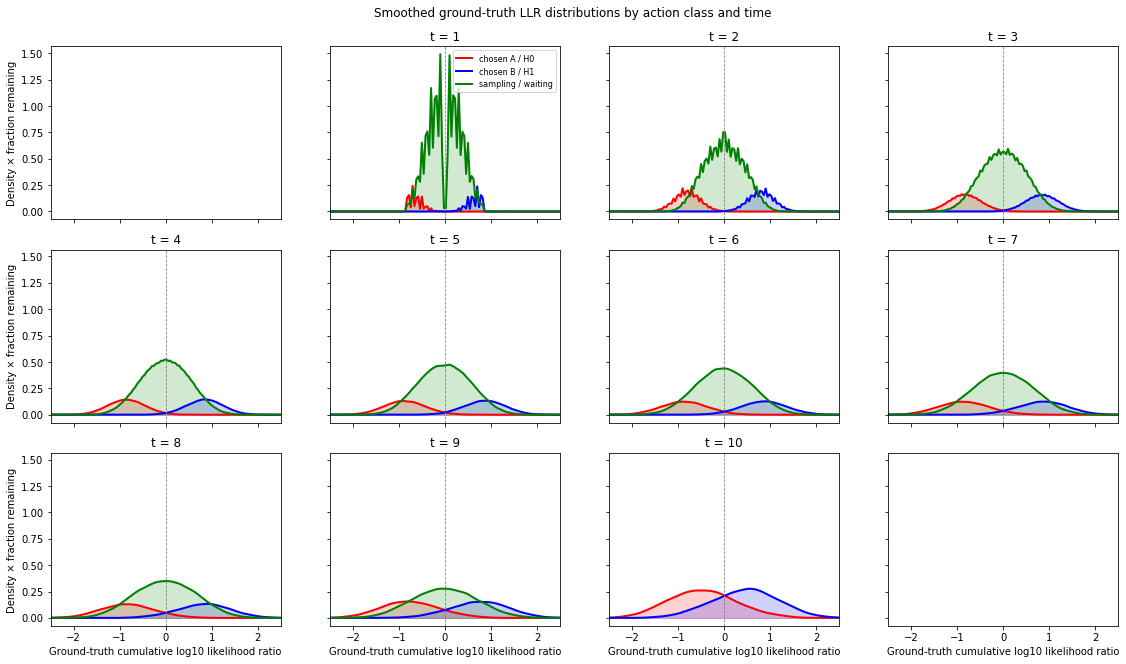

In [31]:
# ============================================================
# 8. Plot smoothed ground-truth LLR distributions by time/action
# ============================================================

from scipy.stats import gaussian_kde

x_eval = np.linspace(-8, 8, 400)

fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.ravel()

def plot_smoothed_envelope(ax, data, n_rem, color, label, bw_adjust=1.0):
    """
    Plot a smoothed density envelope normalized by the number of trials
    remaining at that time step.

    Integral of the curve approximates:
        len(data) / n_rem
    """
    data = np.asarray(data)

    if len(data) < 5:
        return

    kde = gaussian_kde(data)

    # Optional bandwidth adjustment
    kde.set_bandwidth(kde.factor * bw_adjust)

    density = kde(x_eval)

    # Normalize height by fraction of remaining trials in this category
    weight = len(data) / n_rem
    envelope = density * weight

    ax.plot(x_eval, envelope, color=color, linewidth=2, label=label)
    ax.fill_between(x_eval, envelope, color=color, alpha=0.18)

for rec in records[1::]:

    t = rec["t"]
    ax = axes[t]

    n_rem = rec["n_remaining_at_t"]

    plot_smoothed_envelope(
        ax,
        rec["llr_choose_A"],
        n_rem,
        color="red",
        label="chosen A / H0",
        bw_adjust=1.1,
    )

    plot_smoothed_envelope(
        ax,
        rec["llr_choose_B"],
        n_rem,
        color="blue",
        label="chosen B / H1",
        bw_adjust=1.1,
    )

    plot_smoothed_envelope(
        ax,
        rec["llr_wait"],
        n_rem,
        color="green",
        label="sampling / waiting",
        bw_adjust=1.1,
    )

    ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_title(f"t = {t}")
    #ax.set_xlim(x_eval[0], x_eval[-1])
    ax.set_xlim(-2.5, 2.5)

axes[1].legend(fontsize=8)

for ax in axes[-4:]:
    ax.set_xlabel("Ground-truth cumulative log10 likelihood ratio")

for ax in axes[::4]:
    ax.set_ylabel("Density × fraction remaining")

plt.suptitle(
    "Smoothed ground-truth LLR distributions by action class and time",
    y=1.02
)
plt.tight_layout()
plt.show()